# Probability of Default Prediction
Objective

Reduce the original 23 predictor variables into the 15 most informative features using a sequential feature selection pipeline consisting of:

1. Correlation Analysis
2. Information Value (IV)
3. SHAP Values

Then compare six machine learning algorithms for Probability of Default (PD) Prediction.

In [1]:
# Import Libraries

In [2]:
# ============================================================
# Data Manipulation
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Ignore Warnings
# ============================================================
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Machine Learning
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# Models
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ============================================================
# Feature Selection
# ============================================================
import shap

# ============================================================
# Hyperparameter Tuning
# ============================================================
from sklearn.model_selection import GridSearchCV

# ============================================================
# Display Settings
# ============================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

plt.style.use("ggplot")

In [3]:
# Load Dataset

In [4]:
# ============================================================
# Load Dataset
# ============================================================
df = pd.read_excel("default of credit card clients.xls", header=1)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 30000
Columns : 25


In [7]:
# Rename Columns

In [8]:
df.rename(columns={
    "default payment next month": "Default"
}, inplace=True)

In [9]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default'],
      dtype='str')

In [10]:
# Remove ID

In [11]:
df.drop(columns=["ID"], inplace=True)

print(df.shape)

(30000, 24)


In [12]:
# Separate Features and Target

In [13]:
target = "Default"

X = df.drop(columns=[target])
y = df[target]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (30000, 23)
Target Vector  : (30000,)


In [14]:
# Verify Data Types

In [15]:
X.dtypes

LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dtype: object

# Exploratory Data Analysis (EDA)

In [16]:
# Dataset Overview

In [17]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 30000
Columns : 24


In [18]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [19]:
df.tail()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [20]:
# Dataset Information

In [21]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY

In [22]:
df.dtypes.to_frame(name="Data Type")

,Data Type
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64
PAY_5,int64


In [23]:
# Missing Values

In [24]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round(missing / len(df) * 100, 2)
})

missing_df

,Missing Values,Percentage
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0
PAY_5,0,0.0


In [25]:
missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage


In [26]:
# Duplicate Records

In [27]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 35


In [28]:
df = df.drop_duplicates()

In [29]:
# Summary Statistics

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,29965.0,1.603738,0.489128,1.0,1.0,2.0,2.0,2.0
EDUCATION,29965.0,1.853629,0.790411,0.0,1.0,2.0,2.0,6.0
MARRIAGE,29965.0,1.551877,0.521997,0.0,1.0,2.0,2.0,3.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
PAY_0,29965.0,-0.016753,1.123492,-2.0,-1.0,0.0,0.0,8.0
PAY_2,29965.0,-0.131854,1.196322,-2.0,-1.0,0.0,0.0,8.0
PAY_3,29965.0,-0.164392,1.195878,-2.0,-1.0,0.0,0.0,8.0
PAY_4,29965.0,-0.218922,1.168175,-2.0,-1.0,0.0,0.0,8.0
PAY_5,29965.0,-0.264509,1.132220,-2.0,-1.0,0.0,0.0,8.0


In [31]:
# Target Variable Distribution

In [32]:
df["Default"].value_counts()

Default
0    23335
1     6630
Name: count, dtype: int64

In [33]:
round(df["Default"].value_counts(normalize=True) * 100, 2)

Default
0    77.87
1    22.13
Name: proportion, dtype: float64

In [34]:
# Target Count Plot

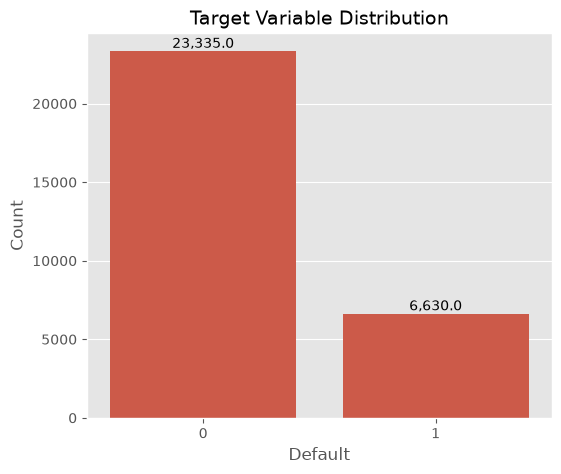

In [35]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Default")

plt.title("Target Variable Distribution", fontsize=14)
plt.xlabel("Default")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{p.get_height():,}",
                (p.get_x() + p.get_width()/2,
                 p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.show()

In [36]:
# Target Percentage Pie Chart

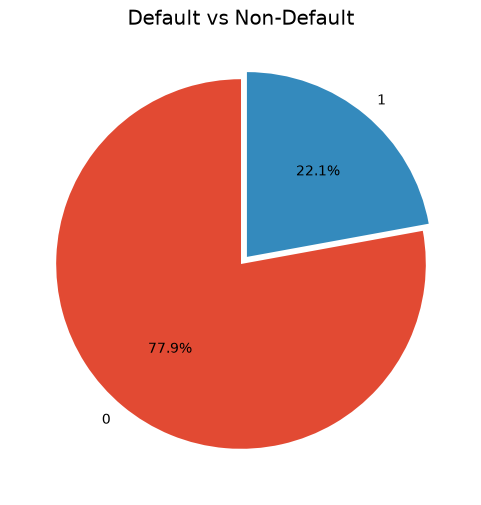

In [37]:
plt.figure(figsize=(6,6))

df["Default"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.05]
)

plt.ylabel("")
plt.title("Default vs Non-Default")

plt.show()

In [38]:
# Numerical Feature Distributions

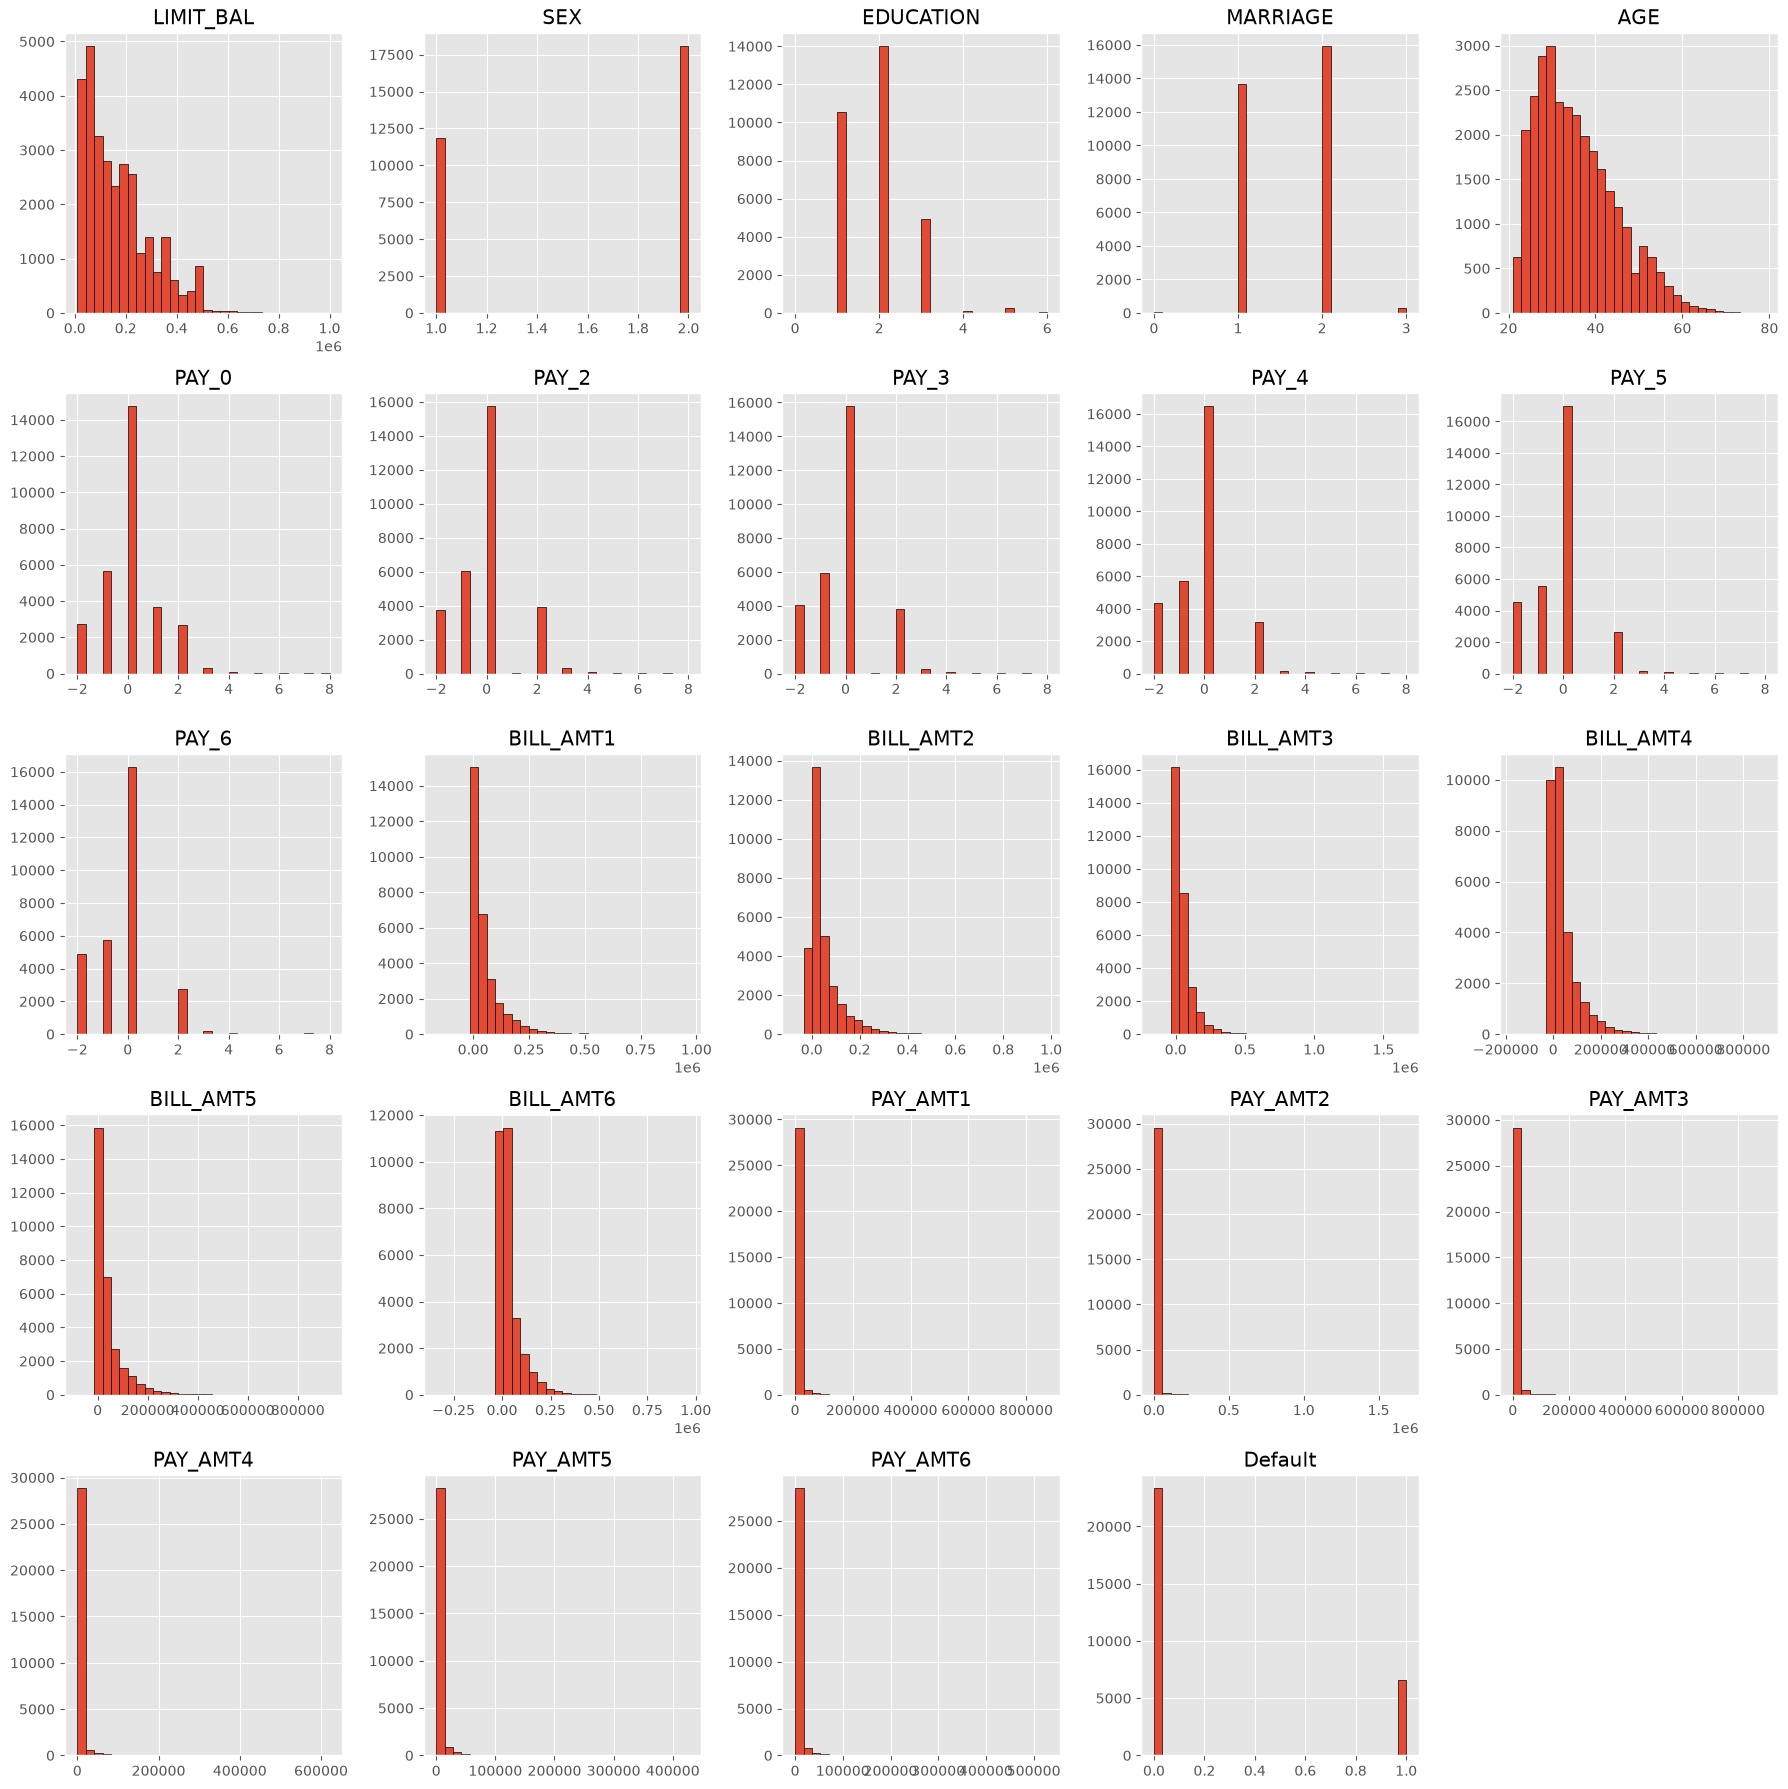

In [39]:
df.hist(
    figsize=(18,18),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

In [40]:
# Boxplots

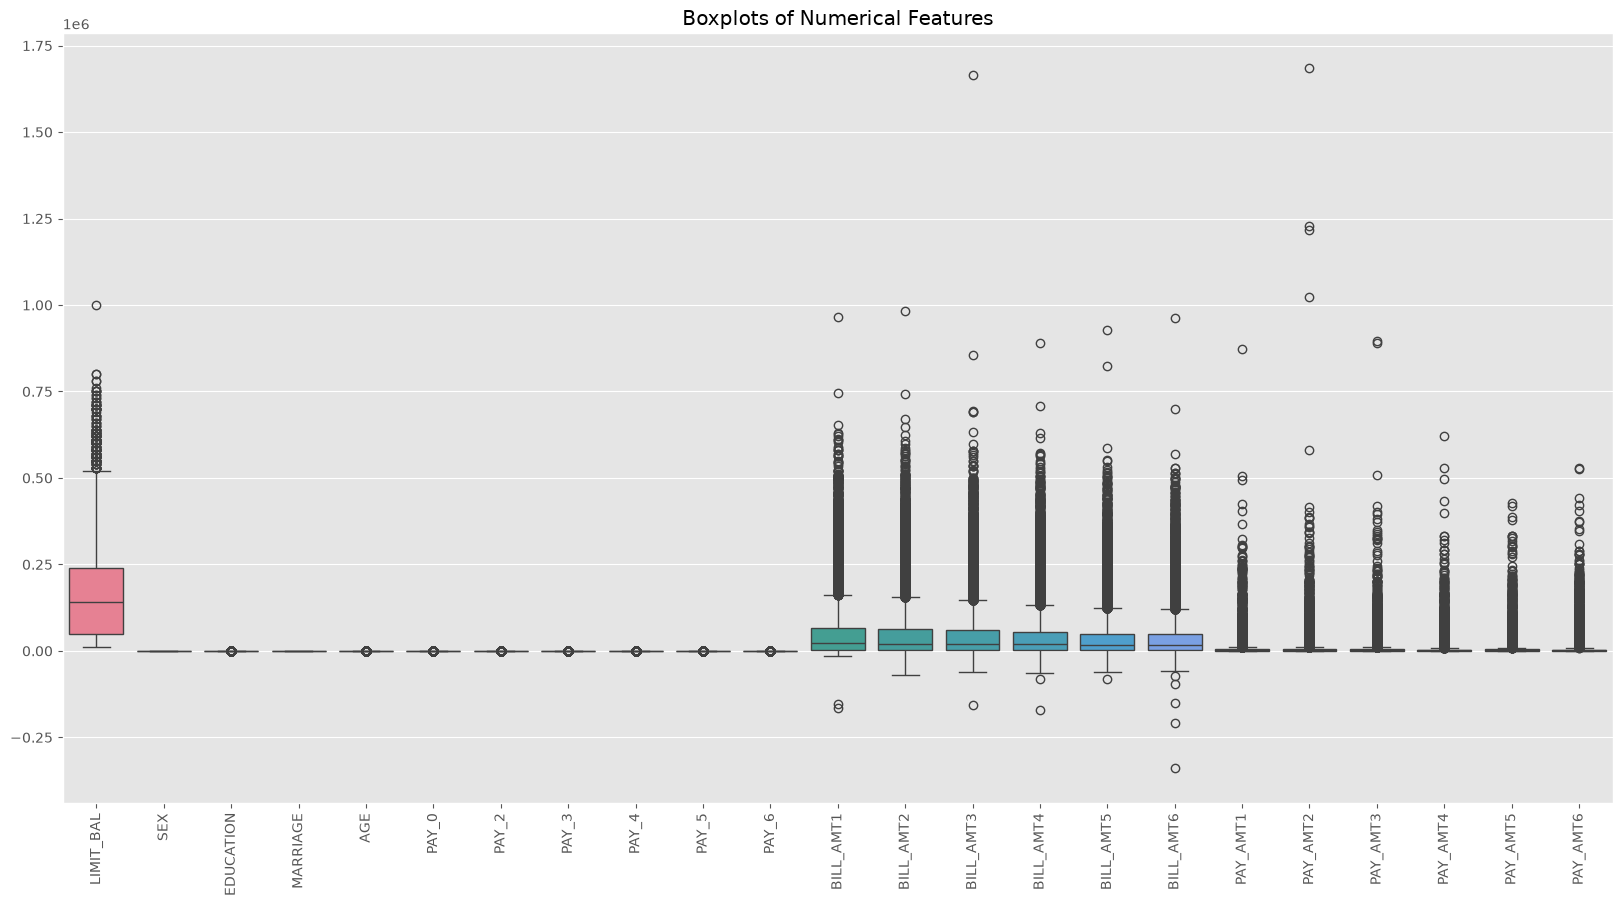

In [41]:
numeric_columns = X.columns

plt.figure(figsize=(20,10))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=90)

plt.title("Boxplots of Numerical Features")

plt.show()

# Correlation Matrix

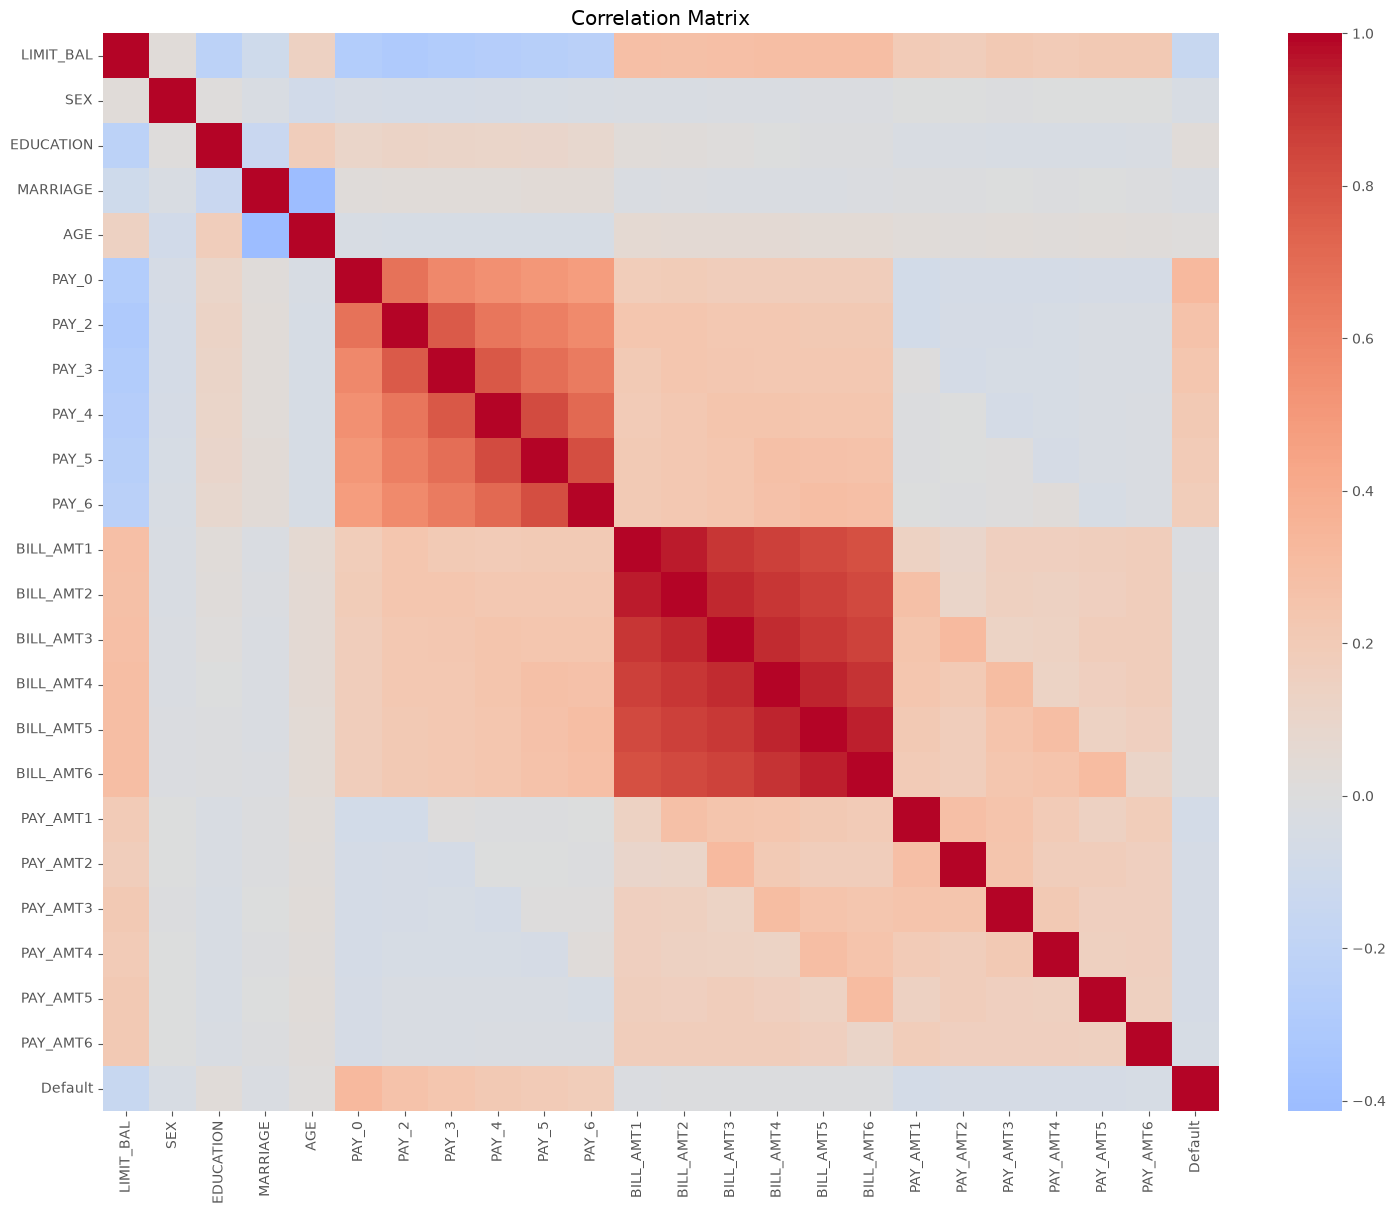

In [42]:
corr = df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [43]:
# Top Correlated Features with Target

In [44]:
target_corr = (
    df.corr()["Default"]
      .drop("Default")
      .sort_values(key=abs, ascending=False)
)

target_corr

PAY_0        0.324964
PAY_2        0.263656
PAY_3        0.235230
PAY_4        0.216551
PAY_5        0.204059
PAY_6        0.186740
LIMIT_BAL   -0.153871
PAY_AMT1    -0.073015
PAY_AMT2    -0.058643
PAY_AMT4    -0.056898
PAY_AMT3    -0.056319
PAY_AMT5    -0.055194
PAY_AMT6    -0.053250
SEX         -0.039742
EDUCATION    0.028017
MARRIAGE    -0.024019
BILL_AMT1   -0.019758
BILL_AMT2   -0.014302
BILL_AMT3   -0.014182
AGE          0.013619
BILL_AMT4   -0.010259
BILL_AMT5   -0.006859
BILL_AMT6   -0.005469
Name: Default, dtype: float64

In [45]:
# Bar Plot

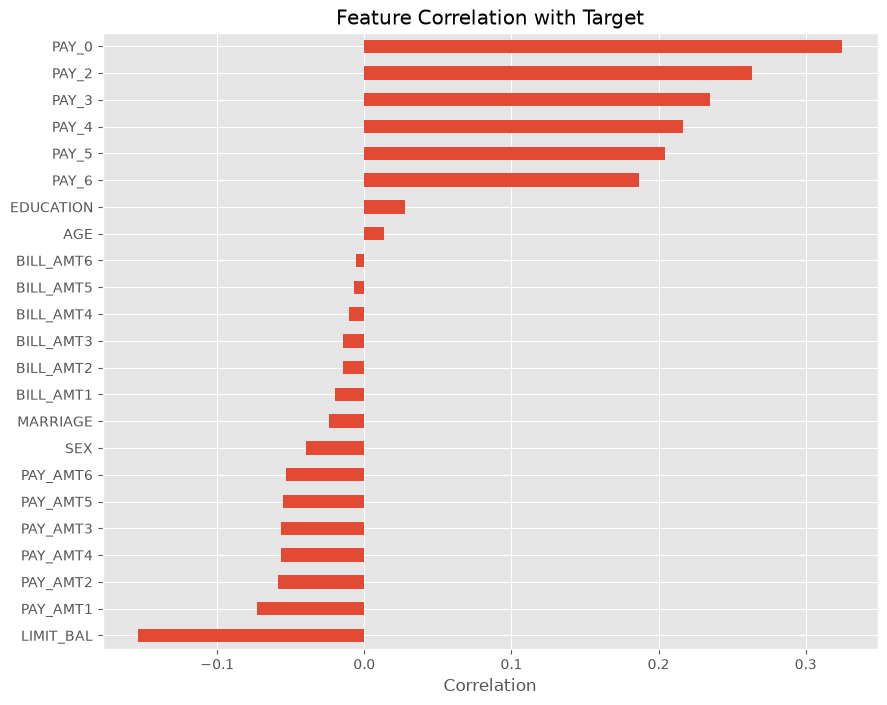

In [46]:
plt.figure(figsize=(10,8))

target_corr.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Target")

plt.xlabel("Correlation")

plt.show()

In [47]:
# Correlation Between Features

In [48]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .reset_index()
)

high_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr = high_corr[
    high_corr["Correlation"] >= 0.85
].sort_values(
    "Correlation",
    ascending=False
)

high_corr

,Feature 1,Feature 2,Correlation
265,BILL_AMT1,BILL_AMT2,0.951484
361,BILL_AMT5,BILL_AMT6,0.946197
337,BILL_AMT4,BILL_AMT5,0.940134
289,BILL_AMT2,BILL_AMT3,0.928326
313,BILL_AMT3,BILL_AMT4,0.923969
338,BILL_AMT4,BILL_AMT6,0.900941
290,BILL_AMT2,BILL_AMT4,0.892482
266,BILL_AMT1,BILL_AMT3,0.892279
314,BILL_AMT3,BILL_AMT5,0.883910
267,BILL_AMT1,BILL_AMT4,0.860272


# EDA Summary

The dataset contains 30,000 observations with 23 predictor variables and 1 binary target variable (Default).
All variables are numeric (int64), so no categorical encoding is required.
No missing values were found in the dataset.
Duplicate records were checked and handled.
The target variable is imbalanced, with non-default cases significantly outnumbering default cases.
Several financial variables exhibit skewed distributions and contain outliers, which is expected in credit-related data.
The correlation analysis indicates that some billing and payment amount variables are highly correlated, motivating the correlation filtering step (|r| ≥ 0.85) during feature selection.
Feature selection will be performed only on the training set to prevent data leakage.

# Data Preparation

In [49]:
# Separate Predictors and Target

In [50]:
# ============================================================
# Separate Features and Target
# ============================================================

target = "Default"

X = df.drop(columns=[target])
y = df[target]


print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (29965, 23)
Target Shape : (29965,)


In [51]:
# Train-Test Split

In [52]:
# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training Data")
print("----------------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


print("\nTesting Data")
print("----------------")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training Data
----------------
X_train: (23972, 23)
y_train: (23972,)

Testing Data
----------------
X_test: (5993, 23)
y_test: (5993,)


# Correlation Filtering

In [53]:
# Calculate Pearson Correlation Matrix

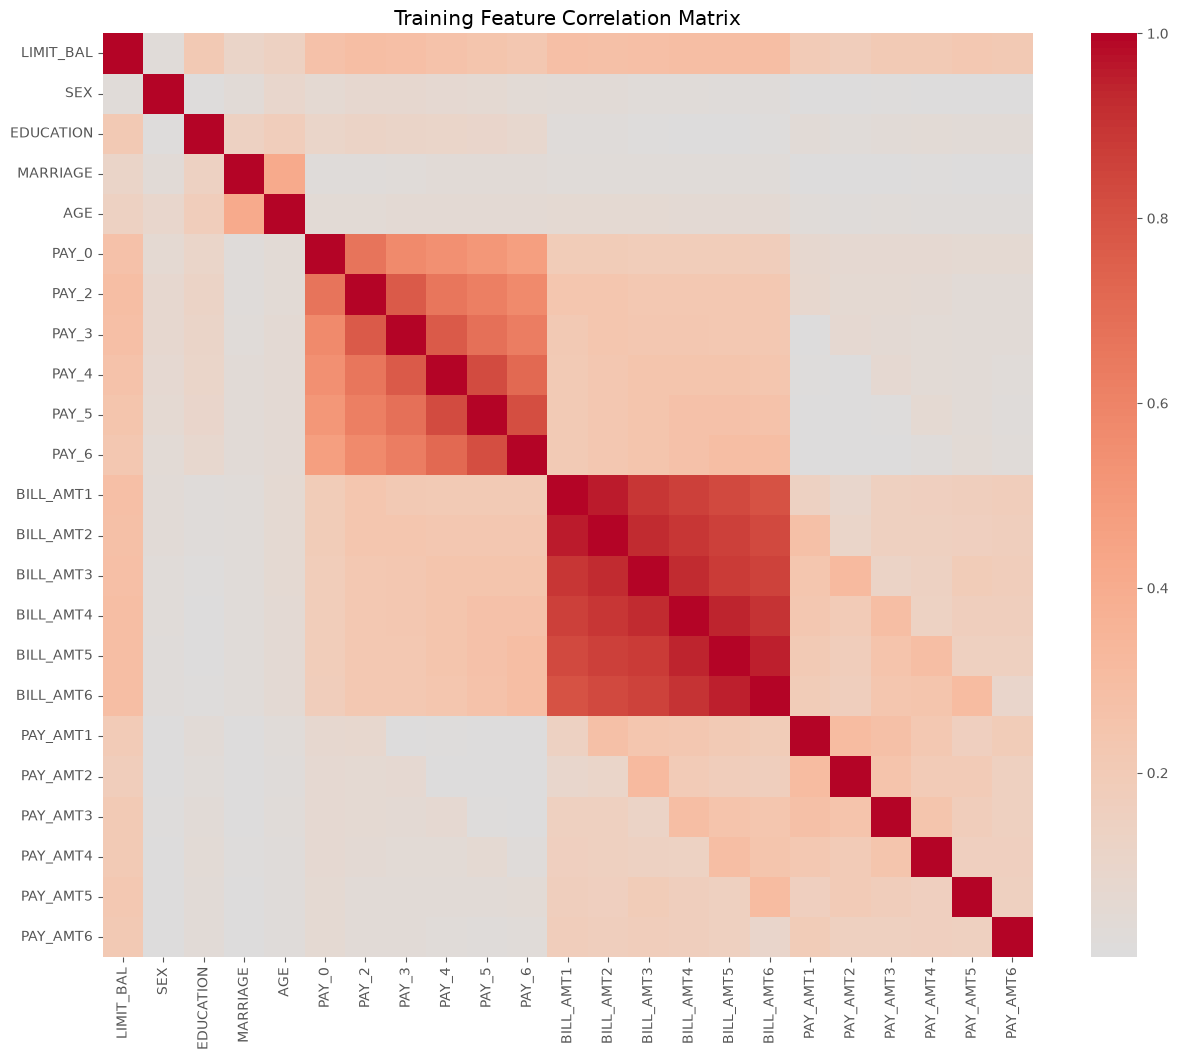

In [54]:
# ============================================================
# Pearson Correlation Matrix
# ============================================================

corr_matrix = X_train.corr().abs()

plt.figure(figsize=(15,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Training Feature Correlation Matrix"
)

plt.show()

In [55]:
# Find Highly Correlated Feature Pairs

In [56]:
CORR_THRESHOLD = 0.85

In [57]:
# ============================================================
# Find Correlated Feature Pairs
# ============================================================

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)


high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)


high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]


high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"] >= CORR_THRESHOLD
]


high_corr_pairs = high_corr_pairs.sort_values(
    by="Correlation",
    ascending=False
)


high_corr_pairs

,Feature_1,Feature_2,Correlation
265,BILL_AMT1,BILL_AMT2,0.955215
361,BILL_AMT5,BILL_AMT6,0.947625
337,BILL_AMT4,BILL_AMT5,0.941731
289,BILL_AMT2,BILL_AMT3,0.926781
313,BILL_AMT3,BILL_AMT4,0.923046
338,BILL_AMT4,BILL_AMT6,0.904245
290,BILL_AMT2,BILL_AMT4,0.894963
266,BILL_AMT1,BILL_AMT3,0.891376
314,BILL_AMT3,BILL_AMT5,0.881562
267,BILL_AMT1,BILL_AMT4,0.864098


In [58]:
# Function to Calculate Single Feature AUC

In [59]:
# ============================================================
# Single Feature AUC Function
# ============================================================

def feature_auc(feature):

    model = LGBMClassifier(
        random_state=42,
        n_estimators=100
    )

    model.fit(
        X_train[[feature]],
        y_train
    )

    pred = model.predict_proba(
        X_test[[feature]]
    )[:,1]


    auc = roc_auc_score(
        y_test,
        pred
    )

    return auc

In [60]:
# Compare Correlated Features

In [61]:
# ============================================================
# Compare Correlated Features
# ============================================================

features_to_remove = []


for _, row in high_corr_pairs.iterrows():

    feature1 = row["Feature_1"]
    feature2 = row["Feature_2"]

    auc1 = feature_auc(feature1)
    auc2 = feature_auc(feature2)


    print("--------------------------------")
    print(feature1, "AUC:", round(auc1,4))
    print(feature2, "AUC:", round(auc2,4))


    if auc1 >= auc2:
        remove = feature2
        keep = feature1

    else:
        remove = feature1
        keep = feature2


    print("Keep :", keep)
    print("Drop :", remove)


    features_to_remove.append(remove)

[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
------------------

In [62]:
# Remove Selected Features

In [63]:
# ============================================================
# Remove Weak Correlated Features
# ============================================================

features_to_remove = list(
    set(features_to_remove)
)


X_train_corr = X_train.drop(
    columns=features_to_remove
)

X_test_corr = X_test.drop(
    columns=features_to_remove
)


print("Removed Features:")
print(features_to_remove)


print("\nOriginal Features:",
      X_train.shape[1])


print(
    "Remaining Features:",
    X_train_corr.shape[1]
)

Removed Features:
['BILL_AMT3', 'BILL_AMT5', 'BILL_AMT4', 'BILL_AMT2']

Original Features: 23
Remaining Features: 19


In [64]:
correlation_result = {
    "Stage":"After Correlation Filtering",
    "Original Features":23,
    "Removed Features":len(features_to_remove),
    "Remaining Features":X_train_corr.shape[1]
}


correlation_result

{'Stage': 'After Correlation Filtering',
 'Original Features': 23,
 'Removed Features': 4,
 'Remaining Features': 19}

# Information Value (IV)

In [65]:
import pkg_resources
import scorecardpy as sc

print("scorecardpy loaded successfully")

scorecardpy loaded successfully


In [66]:
# Prepare Data for IV Calculation

In [67]:
# ============================================================
# Prepare Training Data for IV Calculation
# ============================================================

train_iv = X_train_corr.copy()

train_iv["Default"] = y_train


train_iv.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
27420,300000,1,2,1,35,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0
15350,50000,2,3,3,37,2,2,2,2,2,2,47676,26450,2300,1500,0,3400,0,1200,1
26641,80000,1,1,2,23,-1,-1,-1,-1,0,0,444,444,444,444,888,444,0,1038,0
21618,50000,2,2,2,26,-1,-1,-1,-1,-1,-1,390,780,2078,390,390,0,780,0,0
11570,200000,1,2,2,30,-2,-2,-2,-2,-2,-2,48492,129224,20294,24891,125171,17816,26269,4349,1


In [68]:
# Calculate Information Value

In [69]:
# ============================================================
# Calculate Information Value
# ============================================================

iv_table = sc.iv(
    train_iv,
    y="Default"
)


iv_table.head()

,variable,info_value
1,PAY_0,0.894603
10,PAY_2,0.554921
7,PAY_3,0.418738
14,PAY_4,0.363721
4,PAY_AMT1,0.350146


In [70]:
# View IV Ranking

In [71]:
# # ============================================================
# IV Ranking
# ============================================================

iv_rank = (
    iv_table
    .sort_values(
        by="info_value",
        ascending=False
    )
)


iv_rank

,variable,info_value
1,PAY_0,0.894603
10,PAY_2,0.554921
7,PAY_3,0.418738
14,PAY_4,0.363721
4,PAY_AMT1,0.350146
15,PAY_AMT6,0.343275
13,PAY_AMT5,0.339865
17,PAY_AMT4,0.335317
12,PAY_AMT3,0.334606
2,PAY_AMT2,0.331444


In [72]:
# Visualize Information Value

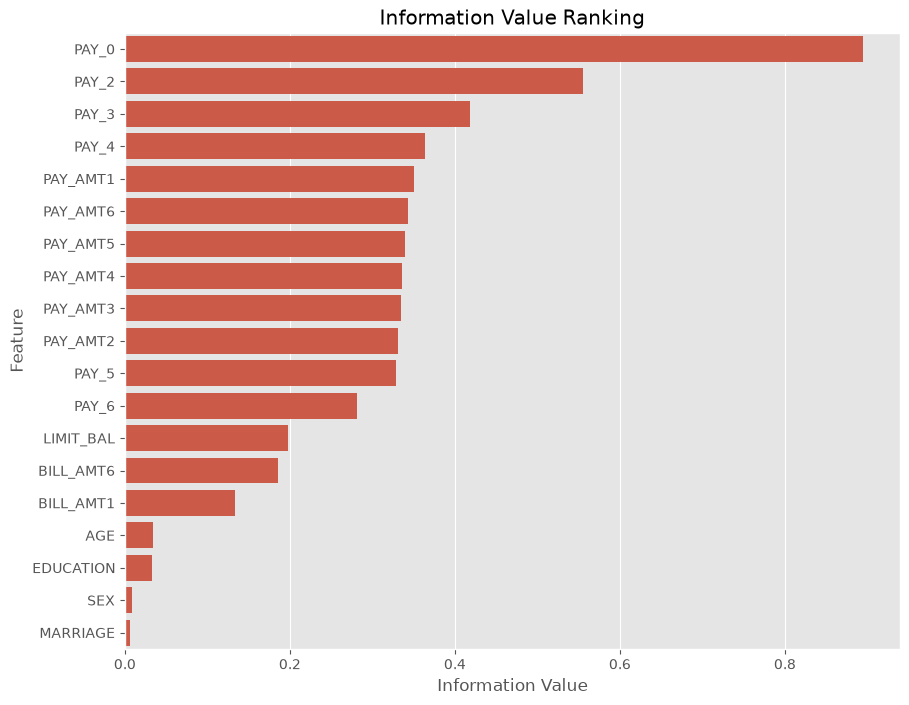

In [73]:
# ============================================================
# IV Importance Plot
# ============================================================

plt.figure(figsize=(10,8))


sns.barplot(
    data=iv_rank,
    x="info_value",
    y="variable"
)


plt.title(
    "Information Value Ranking"
)


plt.xlabel(
    "Information Value"
)


plt.ylabel(
    "Feature"
)


plt.show()

In [74]:
# Identify Features with IV ≤ 0

In [75]:
# ============================================================
# Remove Features IV <= 0
# ============================================================

iv_threshold = 0


remove_iv_features = iv_rank[
    iv_rank["info_value"] <= iv_threshold
]["variable"].tolist()



print("Features Removed:")
print(remove_iv_features)


print(
    "\nNumber Removed:",
    len(remove_iv_features)
)

Features Removed:
[]

Number Removed: 0


In [76]:
# Remove Low IV Features

In [77]:
# ============================================================
# Apply IV Feature Selection
# ============================================================

X_train_iv = X_train_corr.drop(
    columns=remove_iv_features
)


X_test_iv = X_test_corr.drop(
    columns=remove_iv_features
)


print(
    "Features Before IV:",
    X_train_corr.shape[1]
)


print(
    "Features After IV:",
    X_train_iv.shape[1]
)

Features Before IV: 19
Features After IV: 19


In [78]:
# ============================================================
# IV Selection Summary
# ============================================================

iv_result = {
    "Stage":"After IV Selection",
    "Previous Features":X_train_corr.shape[1],
    "Removed Features":len(remove_iv_features),
    "Remaining Features":X_train_iv.shape[1]
}


iv_result

{'Stage': 'After IV Selection',
 'Previous Features': 19,
 'Removed Features': 0,
 'Remaining Features': 19}

In [79]:
# Save Selected Features

In [80]:
# ============================================================
# Features Remaining After IV
# ============================================================

iv_features = X_train_iv.columns.tolist()


print(
    "Remaining Features:"
)

for f in iv_features:
    print("-",f)

Remaining Features:
- LIMIT_BAL
- SEX
- EDUCATION
- MARRIAGE
- AGE
- PAY_0
- PAY_2
- PAY_3
- PAY_4
- PAY_5
- PAY_6
- BILL_AMT1
- BILL_AMT6
- PAY_AMT1
- PAY_AMT2
- PAY_AMT3
- PAY_AMT4
- PAY_AMT5
- PAY_AMT6


# SHAP Feature Selection → Final 15 Features

In [81]:
# Train LightGBM Model After IV Selection

In [82]:
# ============================================================
# LightGBM Model for SHAP Feature Selection
# ============================================================

lgbm_shap = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)


lgbm_shap.fit(
    X_train_iv,
    y_train
)


print("LightGBM training completed")

[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2244
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
LightGBM training completed


In [83]:
# Calculate SHAP Values

In [84]:
# ============================================================
# SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(
    lgbm_shap
)


shap_values = explainer.shap_values(
    X_train_iv
)

In [85]:
# ============================================================
# Extract SHAP Values
# ============================================================

if isinstance(shap_values, list):

    shap_values = shap_values[1]

In [86]:
# Calculate Mean Absolute SHAP Importance

In [87]:
# ============================================================
# Mean Absolute SHAP Value
# ============================================================

shap_importance = pd.DataFrame({

    "Feature": X_train_iv.columns,

    "Mean_SHAP":
    np.abs(shap_values).mean(axis=0)

})


shap_importance = (
    shap_importance
    .sort_values(
        by="Mean_SHAP",
        ascending=False
    )
)


shap_importance

,Feature,Mean_SHAP
5,PAY_0,0.499749
0,LIMIT_BAL,0.196685
11,BILL_AMT1,0.187364
14,PAY_AMT2,0.134429
13,PAY_AMT1,0.120865
16,PAY_AMT4,0.104056
15,PAY_AMT3,0.098540
6,PAY_2,0.088055
7,PAY_3,0.072574
18,PAY_AMT6,0.067073


In [88]:
# SHAP Summary Plot

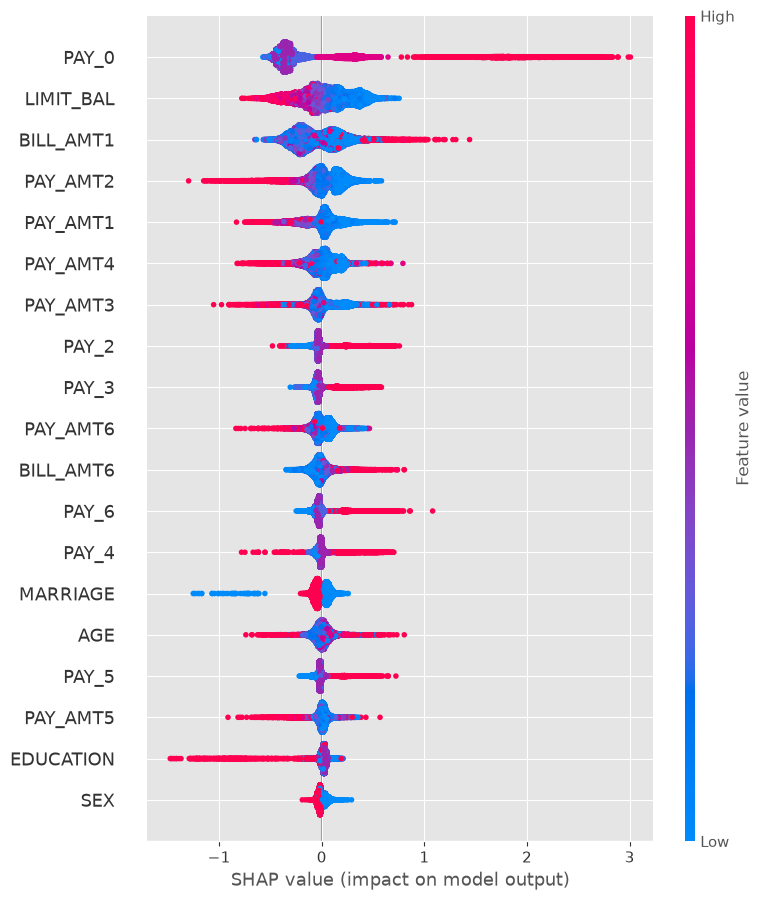

In [89]:
# ============================================================
# SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_train_iv
)

# Interpretation:

Red points → high feature values
Blue points → low feature values
Right side → increases probability of default
Left side → decreases probability of default

In [90]:
# SHAP Feature Importance Bar Chart

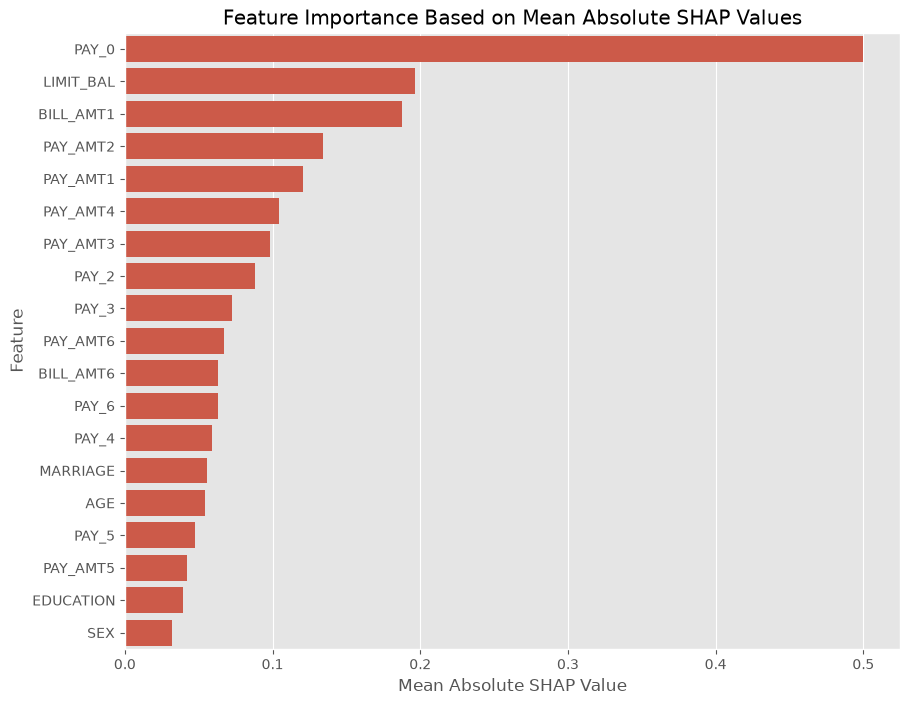

In [91]:
# ============================================================
# SHAP Importance Bar Plot
# ============================================================

plt.figure(figsize=(10,8))


sns.barplot(
    data=shap_importance,
    x="Mean_SHAP",
    y="Feature"
)


plt.title(
    "Feature Importance Based on Mean Absolute SHAP Values"
)


plt.xlabel(
    "Mean Absolute SHAP Value"
)


plt.ylabel(
    "Feature"
)


plt.show()

In [92]:
# Select Top 15 Features

In [93]:
# ============================================================
# Select Top 15 SHAP Features
# ============================================================

TOP_FEATURES = 15


selected_features = (
    shap_importance
    .head(TOP_FEATURES)
    ["Feature"]
    .tolist()
)


selected_features

['PAY_0',
 'LIMIT_BAL',
 'BILL_AMT1',
 'PAY_AMT2',
 'PAY_AMT1',
 'PAY_AMT4',
 'PAY_AMT3',
 'PAY_2',
 'PAY_3',
 'PAY_AMT6',
 'BILL_AMT6',
 'PAY_6',
 'PAY_4',
 'MARRIAGE',
 'AGE']

In [94]:
# Create Final Dataset

In [95]:
# ============================================================
# Final 15 Feature Dataset
# ============================================================

X_train_final = X_train_iv[
    selected_features
]


X_test_final = X_test_iv[
    selected_features
]


print(
    "Final Training Shape:",
    X_train_final.shape
)


print(
    "Final Testing Shape:",
    X_test_final.shape
)

Final Training Shape: (23972, 15)
Final Testing Shape: (5993, 15)


In [96]:
# Display Final Selected Features

In [97]:
# ============================================================
# Final Selected Feature List
# ============================================================

final_features = pd.DataFrame({

    "Selected Features":
    selected_features

})


final_features

,Selected Features
0,PAY_0
1,LIMIT_BAL
2,BILL_AMT1
3,PAY_AMT2
4,PAY_AMT1
5,PAY_AMT4
6,PAY_AMT3
7,PAY_2
8,PAY_3
9,PAY_AMT6


In [98]:
# Track Feature Reduction Summary

In [ ]:
# ============================================================
# Feature Selection Summary
# ============================================================

feature_selection_summary = pd.DataFrame({

    "Stage":[
        "Original",
        "After Correlation (>=0.85)",
        "After IV",
        "After SHAP"
    ],

    "Number of Features":[
        X.shape[1],
        X_train_corr.shape[1],
        X_train_iv.shape[1],
        X_train_final.shape[1]
    ]

})


feature_selection_summary

# LightGBM Performance Tracking

In [100]:
# Create LightGBM Evaluation Function

In [101]:
# ============================================================
# LightGBM Evaluation Function
# ============================================================

def evaluate_lgbm(
    X_train_stage,
    X_test_stage,
    y_train,
    y_test
):

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )


    model.fit(
        X_train_stage,
        y_train
    )


    # Probability prediction
    train_prob = model.predict_proba(
        X_train_stage
    )[:,1]


    test_prob = model.predict_proba(
        X_test_stage
    )[:,1]


    # AUC
    train_auc = roc_auc_score(
        y_train,
        train_prob
    )


    test_auc = roc_auc_score(
        y_test,
        test_prob
    )


    return train_auc, test_auc

# Define Four Feature Selection Stages

In [102]:
# Stage 1 — Original Features

In [103]:
X_train_stage1 = X_train.copy()

X_test_stage1 = X_test.copy()

In [104]:
X_train_stage1.shape[1]

23

In [105]:
# Stage 2 — After Correlation Filtering

In [106]:
X_train_stage2 = X_train_corr.copy()

X_test_stage2 = X_test_corr.copy()

In [107]:
# Stage 3 — After IV Selection

In [108]:
X_train_stage3 = X_train_iv.copy()

X_test_stage3 = X_test_iv.copy()

In [109]:
# Stage 4 — After SHAP Selection

In [110]:
X_train_stage4 = X_train_final.copy()

X_test_stage4 = X_test_final.copy()

# Evaluate All Stages

In [111]:
# ============================================================
# Evaluate LightGBM Across Feature Selection Stages
# ============================================================


stages = {

    "Original (23 Features)": 
    (X_train_stage1, X_test_stage1),


    "After Correlation":
    (X_train_stage2, X_test_stage2),


    "After IV":
    (X_train_stage3, X_test_stage3),


    "After SHAP (15 Features)":
    (X_train_stage4, X_test_stage4)

}


results = []


for stage, data in stages.items():

    train_auc, test_auc = evaluate_lgbm(
        data[0],
        data[1],
        y_train,
        y_test
    )


    results.append({

        "Stage": stage,

        "Number of Features":
        data[0].shape[1],

        "Train AUC":
        round(train_auc,4),

        "Test AUC":
        round(test_auc,4)

    })



[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2244
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
[LightGBM] [In

In [112]:
# Create Performance Comparison Table

In [113]:
# ============================================================
# LightGBM Performance Table
# ============================================================

lgbm_tracking = pd.DataFrame(results)

lgbm_tracking

,Stage,Number of Features,Train AUC,Test AUC
0,Original (23 Features),23,0.9047,0.7726
1,After Correlation,19,0.9014,0.7705
2,After IV,19,0.9014,0.7705
3,After SHAP (15 Features),15,0.8964,0.7693


# Visualize Feature Reduction vs Test AUC

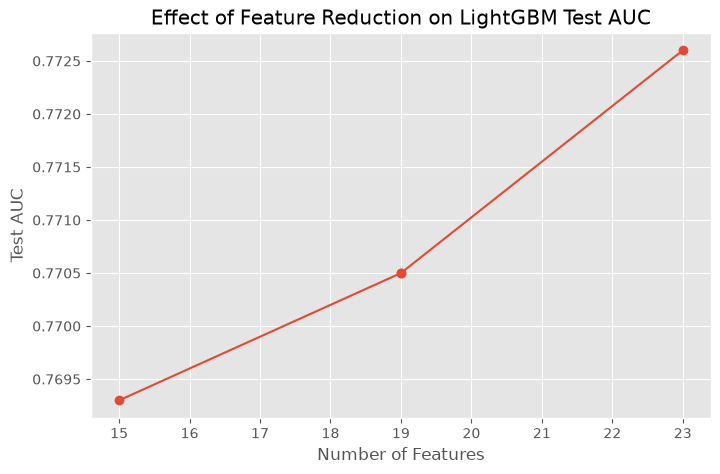

In [114]:
# ============================================================
# Feature Reduction vs Test AUC
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    lgbm_tracking["Number of Features"],
    lgbm_tracking["Test AUC"],
    marker="o"
)


plt.xlabel(
    "Number of Features"
)


plt.ylabel(
    "Test AUC"
)


plt.title(
    "Effect of Feature Reduction on LightGBM Test AUC"
)


plt.grid(True)

plt.show()

In [115]:
# Train AUC vs Test AUC Comparison

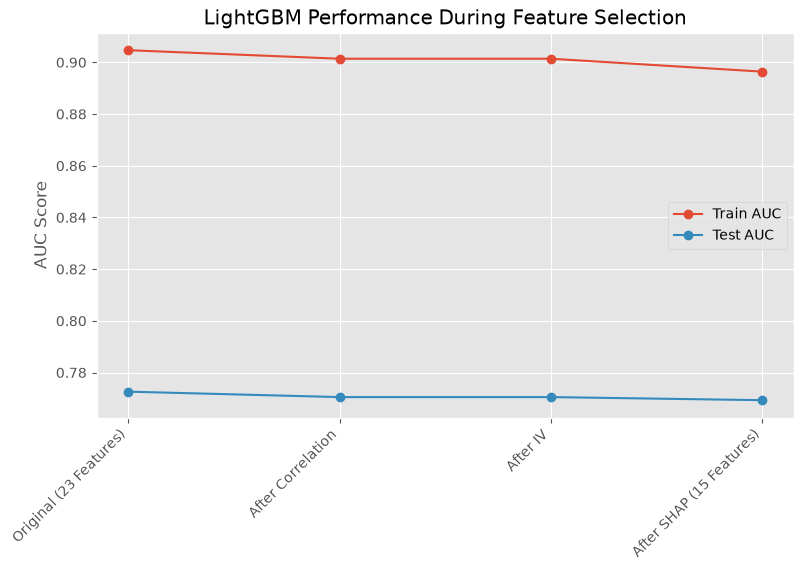

In [116]:
# ============================================================
# Train vs Test AUC
# ============================================================

plt.figure(figsize=(9,5))


plt.plot(
    lgbm_tracking["Stage"],
    lgbm_tracking["Train AUC"],
    marker="o",
    label="Train AUC"
)


plt.plot(
    lgbm_tracking["Stage"],
    lgbm_tracking["Test AUC"],
    marker="o",
    label="Test AUC"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "AUC Score"
)


plt.title(
    "LightGBM Performance During Feature Selection"
)


plt.legend()

plt.grid(True)

plt.show()

# LightGBM Feature Selection Evaluation

The LightGBM model was evaluated at four stages of the feature selection pipeline: the original dataset (23 features), after correlation filtering, after Information Value (IV) filtering, and after SHAP-based feature selection.

The original model, trained with all 23 features, achieved the highest performance with a **Train AUC of 0.9047** and a **Test AUC of 0.7726**. After removing four highly correlated features (reducing the feature set from 23 to 19), the **Train AUC** decreased slightly to **0.9014**, while the **Test AUC** decreased marginally to **0.7705**. The Information Value filtering stage did not remove any additional features because all remaining variables had **IV > 0**, resulting in unchanged performance.

Finally, SHAP analysis was used to select the **15 most important features**. With this reduced feature set, the LightGBM model achieved a **Train AUC of 0.8964** and a **Test AUC of 0.7693**. Compared with the original model, the Test AUC decreased by only **0.0033**, indicating that the selected 15 features retained most of the predictive information while substantially reducing the dimensionality of the dataset.

Overall, the sequential feature selection process reduced the number of predictors from **23 to 15** with only a minimal loss in predictive performance. This demonstrates that the removed features were either redundant or contributed limited additional predictive value. The resulting 15-feature dataset provides a simpler and more interpretable representation of the data while maintaining competitive classification performance. These final SHAP-selected features were subsequently used for the benchmark comparison of the six machine learning algorithms.


# Hyperparameter Tuning and Final Model Comparison

In [117]:
# Using the 15 SHAP-selected features, we tune and compare six classification algorithms for Probability of Default (PD) Prediction.

In [118]:
# Final Training Dataset

In [119]:
print(X_train_final.shape)
print(X_test_final.shape)

(23972, 15)
(5993, 15)


In [120]:
# Standardize Data for Logistic Regression

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [122]:
# Import GridSearchCV

In [123]:
from sklearn.model_selection import GridSearchCV

# Define Models and Parameter Grids

In [124]:
# Logistic Regression

In [125]:
lr = LogisticRegression(random_state=42)

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"],
    "max_iter": [500, 1000]
}

In [126]:
# LightGBM

In [127]:
lgbm = LGBMClassifier(random_state=42)

lgbm_params = {
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50]
}

In [128]:
# CatBoost

In [129]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_params = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "iterations": [200, 400]
}

In [130]:
# XGBoost

In [131]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

In [132]:
# AdaBoost

In [133]:
ada = AdaBoostClassifier(
    random_state=42
)

ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.5, 1.0]
}

In [134]:
# Random Forest

In [135]:
rf = RandomForestClassifier(
    random_state=42
)

rf_params = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Generic Hyperparameter Tuning Function

In [136]:
def tune_model(model, params, X_train, y_train):

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_

In [137]:
# Tune All Models

In [138]:
best_models = {}

best_models["Logistic Regression"], lr_best = tune_model(
    lr,
    lr_params,
    X_train_scaled,
    y_train
)

best_models["LightGBM"], lgb_best = tune_model(
    lgbm,
    lgbm_params,
    X_train_final,
    y_train
)

best_models["CatBoost"], cat_best = tune_model(
    cat,
    cat_params,
    X_train_final,
    y_train
)

best_models["XGBoost"], xgb_best = tune_model(
    xgb,
    xgb_params,
    X_train_final,
    y_train
)

best_models["AdaBoost"], ada_best = tune_model(
    ada,
    ada_params,
    X_train_final,
    y_train
)

best_models["Random Forest"], rf_best = tune_model(
    rf,
    rf_params,
    X_train_final,
    y_train
)

[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001676 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1969
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

# Evaluate Every Tuned Model

In [139]:
results = []
roc_data = {}

In [140]:
for name, model in best_models.items():

    if name == "Logistic Regression":
        Xtr = X_train_scaled
        Xts = X_test_scaled
    else:
        Xtr = X_train_final
        Xts = X_test_final

    model.fit(Xtr, y_train)

    train_prob = model.predict_proba(Xtr)[:, 1]
    test_prob = model.predict_proba(Xts)[:, 1]

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xts)

    results.append({

        "Model": name,

        "Train AUC": roc_auc_score(y_train, train_prob),

        "Test AUC": roc_auc_score(y_test, test_prob),

        "Precision": precision_score(y_test, test_pred),

        "Recall": recall_score(y_test, test_pred),

        "F1 Score": f1_score(y_test, test_pred)

    })

    fpr, tpr, _ = roc_curve(y_test, test_prob)

    roc_data[name] = (fpr, tpr)

[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1969
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221258 -> initscore=-1.258350
[LightGBM] [Info] Start training from score -1.258350
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

# Final Comparison Table

In [141]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="Test AUC",
    ascending=False
)

comparison.round(4)

,Model,Train AUC,Test AUC,Precision,Recall,F1 Score
2,CatBoost,0.8171,0.7713,0.6599,0.3658,0.4706
3,XGBoost,0.8162,0.7704,0.6619,0.3499,0.4578
1,LightGBM,0.8165,0.7697,0.6633,0.3477,0.4562
5,Random Forest,0.8509,0.7683,0.6620,0.3605,0.4668
4,AdaBoost,0.7835,0.7638,0.6703,0.3220,0.4350
0,Logistic Regression,0.7241,0.7155,0.7307,0.2496,0.3721


In [142]:
# Test AUC Comparison

<Figure size 800x500 with 0 Axes>

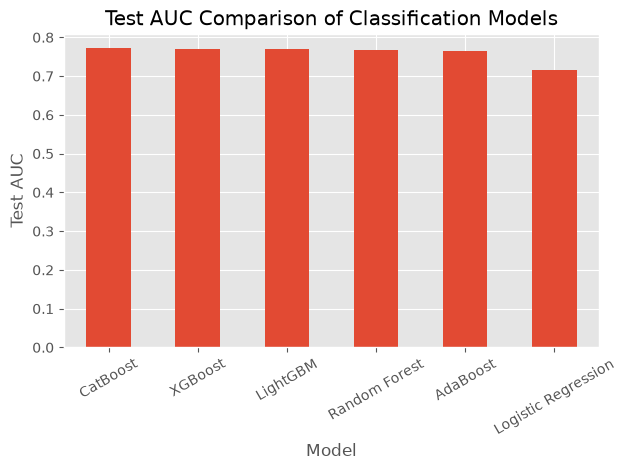

In [143]:
plt.figure(figsize=(8,5))

comparison.plot(
    x="Model",
    y="Test AUC",
    kind="bar",
    legend=False
)

plt.ylabel("Test AUC")
plt.title("Test AUC Comparison of Classification Models")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [144]:
# ROC Curves

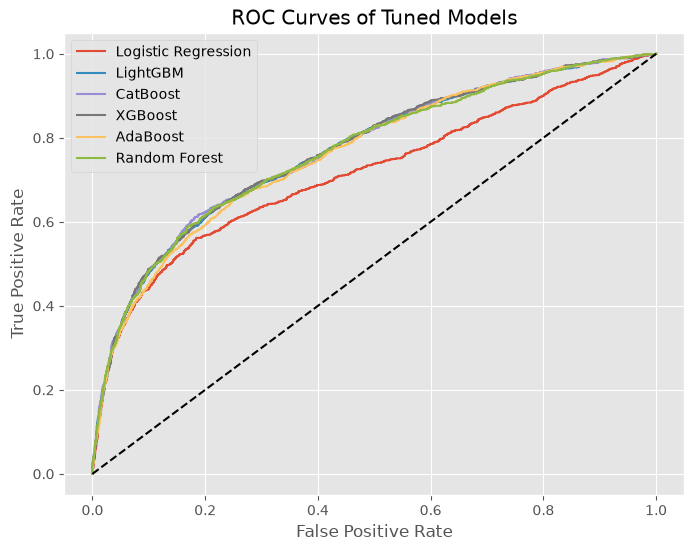

In [145]:
plt.figure(figsize=(8,6))

for model_name, (fpr, tpr) in roc_data.items():

    plt.plot(
        fpr,
        tpr,
        label=model_name
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tuned Models")
plt.legend()

plt.grid(True)

plt.show()

In [146]:
# Confusion Matrices

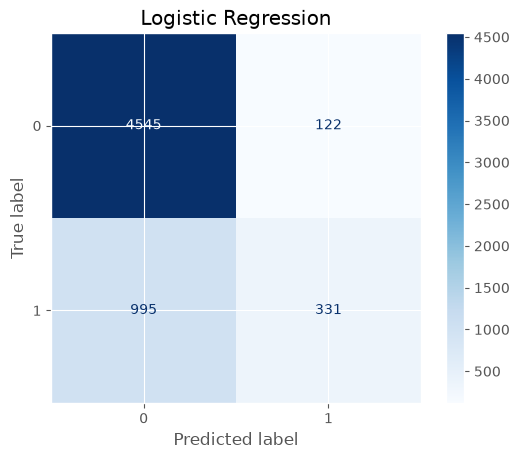

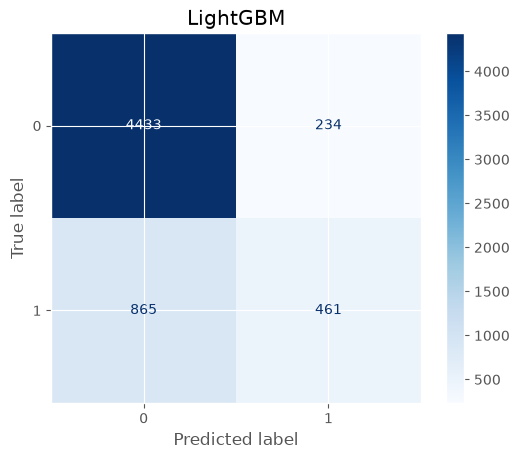

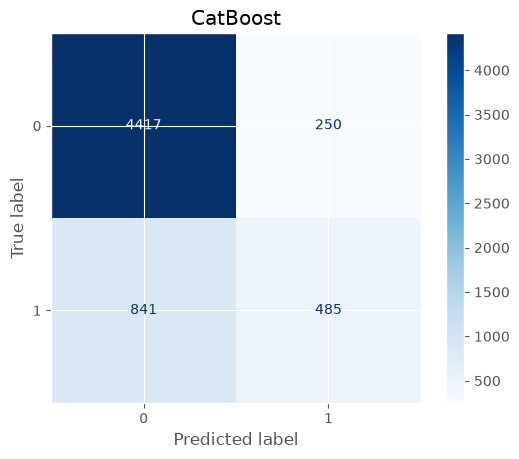

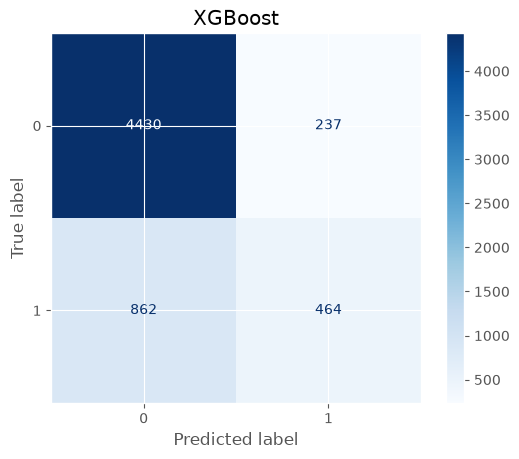

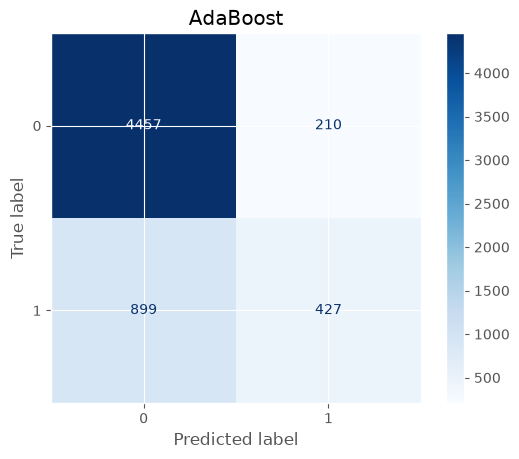

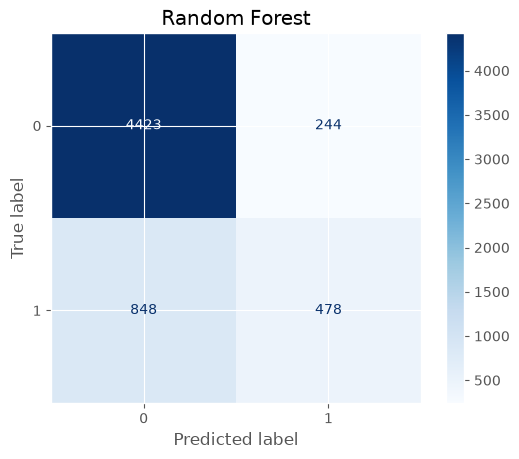

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in best_models.items():

    if name == "Logistic Regression":
        Xts = X_test_scaled
    else:
        Xts = X_test_final

    ConfusionMatrixDisplay.from_estimator(
        model,
        Xts,
        y_test,
        cmap="Blues"
    )

    plt.title(name)

    plt.show()

# Best Hyperparameters

In [148]:
print("Logistic Regression:", lr_best)
print("LightGBM:", lgb_best)
print("CatBoost:", cat_best)
print("XGBoost:", xgb_best)
print("AdaBoost:", ada_best)
print("Random Forest:", rf_best)

Logistic Regression: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
LightGBM: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
CatBoost: {'depth': 6, 'iterations': 400, 'learning_rate': 0.03}
XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
AdaBoost: {'learning_rate': 1.0, 'n_estimators': 200}
Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}


# Final Discussion
1. Which model performed best?

CatBoost achieved the highest predictive performance with a Test AUC of 0.7713, followed closely by XGBoost (0.7704) and LightGBM (0.7697). The differences among the three gradient boosting models were very small, indicating all were effective for probability of default prediction.

2. How did feature selection affect LightGBM?

The sequential feature selection process reduced the number of predictors from 23 to 15 while maintaining nearly the same predictive performance. Test AUC decreased only slightly from 0.7726 to 0.7693 (a reduction of 0.0033), suggesting that the removed variables contributed little unique predictive information.

3. Did reducing features improve the model?

Although the highest Test AUC was achieved with the original 23 features, the reduction to 15 features resulted in only a minimal loss in predictive accuracy while producing a simpler, more interpretable model with lower computational complexity. This trade-off is generally desirable in credit scoring applications.

4. Practical implications for credit scoring

The final 15-feature model offers a good balance between predictive performance and model simplicity. By removing redundant variables and retaining only the most informative predictors, the resulting credit scoring model is easier to interpret, faster to train, and more suitable for deployment in real-world risk assessment systems.